# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [1]:
!uv pip install numpy

Audited 1 package in 14ms


In [2]:
# Import required libraries
import duckdb
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# no decimals, show thousands separators, no scientific notation
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)

# show more columns/width if needed
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 120)

In [4]:
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

✅ JupySQL configured!


In [5]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [6]:
%%sql
-- Load data into DuckDB tables
CREATE
OR REPLACE TABLE usage_data AS
SELECT
  *
FROM
  'data/usage_by_subscription_period.csv';

CREATE
OR REPLACE TABLE plan_events AS
SELECT
  *
FROM
  'data/plan_change_events.csv';

CREATE
OR REPLACE TABLE projects AS
SELECT
  *
FROM
  'data/projects.csv';

,Count
0,3


In [7]:
%%sql
-- Verify data loading
SELECT
  'usage_data' AS table_name,
  COUNT(*) AS row_count,
  COUNT(DISTINCT subscription_id) AS unique_subscriptions
FROM
  usage_data
UNION ALL
SELECT
  'plan_events' AS table_name,
  COUNT(*) AS row_count,
  COUNT(DISTINCT plan_id) AS unique_plans
FROM
  plan_events
UNION ALL
SELECT
  'projects' AS table_name,
  COUNT(*) AS row_count,
  COUNT(DISTINCT project_id__hashed) AS unique_projects
FROM
  projects;

,table_name,row_count,unique_subscriptions
0,usage_data,53565,8457
1,plan_events,209,36
2,projects,3,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with

# General Assumptions

### For questions 1,2 & 3 (Connectivity Team only cares about project_integration = 'Connect')
- Therefore, all usage data has been limited to project_integration = 'Connnect'


### Data reliability is good

- Given the suggested 3-4 hours to complete this task, I'm operating under the assumption that the data is sound. I haven't invested time in any data prep or cleaning.


### Usage refers to Data rather than minutes

- Given phone usage typically revolves around data (GB) these days, I've used "Data" rather than "minutes"
- Further analysis on minutes would also make sense, to validate this assumption

### Create quick helper function to query and return data as DF

In [94]:
def sql_to_df(query=None):
    df = %sql {{query}}
    return df

# 1. How much data does a subscription typically consume?

### Query

In [78]:
query_avg_usage = """

with plan_usage_per_subscription as (
    select
          ud.subscription_id
        , sum(ud.cumulative_data_usage_megabyte / 1000) as total_data_usage
        , (avg(ud.cumulative_data_usage_megabyte) / 1000)  as avg_data_usage_gb
    from usage_data ud
    
    left join projects p
        on ud.project_id__hashed = p.project_id__hashed

    where p.project_type = 'Connect'
    
    group by all
),

avg_monthly_usage as (   
    select
          'Avg. Monthly Usage (GB)' as segment
        , avg(avg_data_usage_gb::decimal(18,1)) as data_consumption
    from plan_usage_per_subscription
    
    where avg_data_usage_gb > 0
    
    group by all order by 1 asc
),

lifetime_usage as (
    select
          'Avg. Lifetime Usage (GB)' as segment
        , sum(total_data_usage) / count(distinct subscription_id) as data_consumption
    from plan_usage_per_subscription
    
    group by all
)

select * from avg_monthly_usage
    union all
select * from lifetime_usage

"""

df_avg_usage = sql_to_df(query_avg_usage)
df_avg_usage

,segment,data_consumption
0,Avg. Monthly Usage (GB),1.38
1,Avg. Lifetime Usage (GB),7.61


### Visualisation

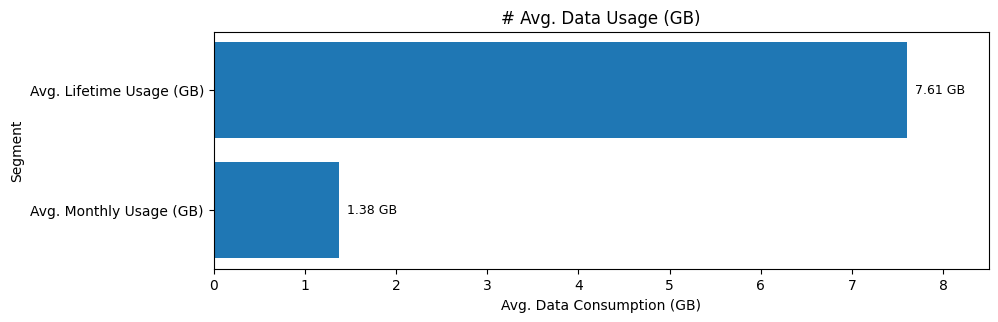

In [83]:
#Create Fig
fig, ax = plt.subplots(figsize=(10,3))


# Plot Subscriptions (Bar Chart)
bars = ax.barh(df_avg_usage["segment"], df_avg_usage["data_consumption"])
ax.set_xlim(0, 8.5)


# Chart Title / X & Y Formatting
ax.set_xlabel("Avg. Data Consumption (GB)")
ax.set_ylabel("Segment")
ax.set_title("# Avg. Data Usage (GB)")


# value labels on bars
for p in ax.patches:
    w = p.get_width()
    ax.annotate(f'{w:.2f} GB', (w, p.get_y() + p.get_height()/2), xytext=(6, 0), textcoords='offset points', va='center', ha='left', fontsize=9)


# Legends
plt.subplots_adjust(top=0.90)


# 2. How does usage look like at different plan data allowances?

### Query

In [85]:
sql_usage_by_plan_allowance = """

with data_allowance_per_plan as (
    select distinct
          plan_id
        , case when data_allowance_mb is null then 'Unlimited' else (cast(round(data_allowance_mb/1000,0) as varchar) || ' GB') end as plan_allowance_name_gb
        , data_allowance_mb/1000 as plan_allowance_value_gb
    from plan_events
),

usage_data_enriched as (
    select
          ud.subscription_id
        , ud.reporting_date
        , ud.cumulative_data_usage_megabyte
        , dapp.plan_allowance_name_gb
        , dapp.plan_allowance_value_gb
    from usage_data ud
    
    left join data_allowance_per_plan dapp
        on ud.plan_id = dapp.plan_id
        
    left join projects p
        on ud.project_id__hashed = p.project_id__hashed

    where p.project_type = 'Connect'
),

usage_data_final as (
    select
          plan_allowance_name_gb
        , count(distinct subscription_id) as subscriptions
        , avg(cumulative_data_usage_megabyte / 1000) as avg_monthly_usage_gb
        , sum(cumulative_data_usage_megabyte / 1000) / count(distinct subscription_id) as total_avg_usage_gb
    from usage_data_enriched
    group by all 
)

select * from usage_data_final order by 3 desc

"""

df_usage_by_plan = sql_to_df(sql_usage_by_plan_allowance)
df_usage_by_plan.head(5)

,plan_allowance_name_gb,subscriptions,avg_monthly_usage_gb,total_avg_usage_gb
0,Unlimited,1302,7.51,28.46
1,5.0 GB,842,1.68,6.35
2,1.0 GB,5963,0.37,2.74


#### Quick observations & Findings

- Data usage is somewhat expected. Where usage Unlimited > 5GB > 1GB
- Size of cohorts suggests users are rather drawn to the extremes (1GB of Unlimited) with fewer users taking the 5GB plan

### Visualisation

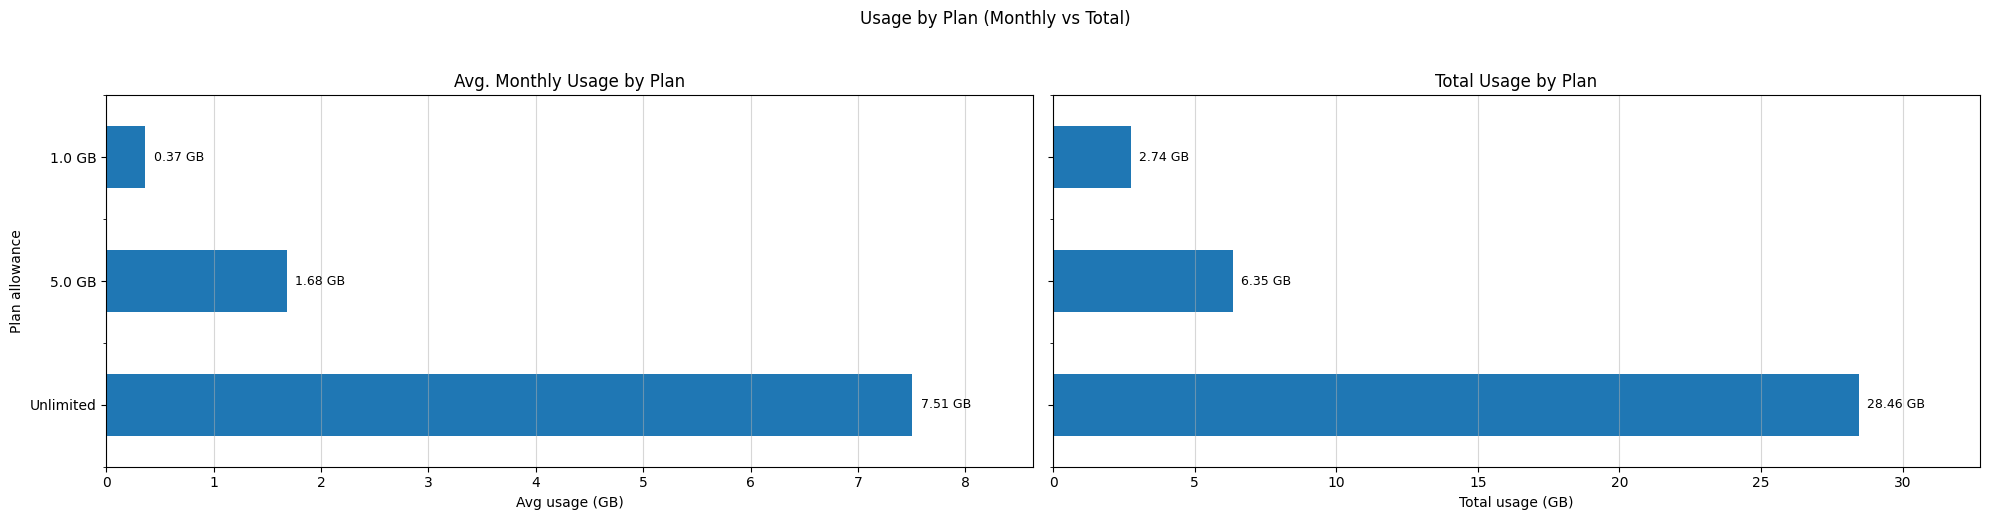

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Order + prep (aggregate just in case there are multiple rows per plan)
order = ["Unlimited", "5.0 GB", "1.0 GB"]

g = (df_usage_by_plan
       .groupby("plan_allowance_name_gb", as_index=True)
       .agg(monthly=("avg_monthly_usage_gb", "mean"),
            total=("total_avg_usage_gb", "sum"))
       .reindex(order)
       .dropna())

# 2) Two barh charts side-by-side (share the y labels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

# Left: Avg monthly usage
g["monthly"].plot(kind="barh", ax=ax1, legend=False)
ax1.set_title("Avg. Monthly Usage by Plan")
ax1.set_xlabel("Avg usage (GB)")
ax1.set_ylabel("Plan allowance")
ax1.grid(axis="x", alpha=0.5)
ax1.invert_yaxis()  # first item at the top
ax1.set_xlim(0, g["monthly"].max() * 1.15)

for p in ax1.patches:
    w = p.get_width()
    ax1.annotate(f"{w:.2f} GB", (w, p.get_y() + p.get_height()/2), xytext=(6, 0), textcoords="offset points", va="center", ha="left", fontsize=9)

# Right: Total usage
g["total"].plot(kind="barh", ax=ax2, legend=False)
ax2.set_title("Total Usage by Plan")
ax2.set_xlabel("Total usage (GB)")
ax2.grid(axis="x", alpha=0.5)
ax2.set_xlim(0, g["total"].max() * 1.15)

for p in ax2.patches:
    w = p.get_width()
    ax2.annotate(f"{w:,.2f} GB", (w, p.get_y() + p.get_height()/2), xytext=(6, 0), textcoords="offset points", va="center", ha="left", fontsize=9)

fig.suptitle("Usage by Plan (Monthly vs Total)", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()


# 3. Do subscriptions typically consume consistent amounts of data throughout their lifetime?

### Query

In [55]:
sql_usage_by_plan_allowance = """

with data_allowance_per_plan as (
    select distinct
          plan_id
        , case when data_allowance_mb is null then 'Unlimited' else (cast(data_allowance_mb/1000 as varchar) || 'GB') end as plan_allowance_name_gb
        , data_allowance_mb/1000 as plan_allowance_value_gb
    from plan_events
),

usage_data_enriched as (
    select
          ud.subscription_id
        , ud.plan_id
        , ud.subscription_period_number
        , ud.project_id__hashed
        , ud.reporting_date
        , ud.subscription_period_start
        , ud.subscription_period_end
        , ud.cumulative_data_usage_megabyte
        , dapp.plan_allowance_name_gb
        , dapp.plan_allowance_value_gb
    from usage_data ud
    
    left join data_allowance_per_plan dapp
        on ud.plan_id = dapp.plan_id

    left join projects p
        on ud.project_id__hashed = p.project_id__hashed
        
    where p.project_type = 'Connect'
),

usage_data_final as (
    select
          plan_allowance_name_gb
        , subscription_period_number
        , count(distinct subscription_id) as subscriptions
        , avg(cumulative_data_usage_megabyte / 1000) as avg_usage_gb
        , sum(cumulative_data_usage_megabyte / 1000) as total_usage_gb
        , count(reporting_date) as active_months
    from usage_data_enriched
    group by all
)

select * from usage_data_final order by 3 desc
"""

df = sql_to_df(sql_usage_by_plan_allowance)
df.head(20)

,plan_allowance_name_gb,subscription_period_number,subscriptions,avg_usage_gb,total_usage_gb,active_months
0,1.0GB,1,5843,0.43,"2,546.37",5862
1,1.0GB,2,5173,0.38,"1,963.74",5188
2,1.0GB,3,4536,0.41,"1,874.56",4545
3,1.0GB,4,4124,0.35,"1,454.85",4131
4,1.0GB,5,3735,0.39,"1,467.67",3742
5,1.0GB,6,3452,0.39,"1,361.01",3452
6,1.0GB,7,3211,0.35,"1,125.24",3214
7,1.0GB,8,2924,0.35,"1,019.32",2927
8,1.0GB,9,2688,0.33,874.35,2688
9,1.0GB,10,2434,0.29,715.37,2437


In [56]:
#### Visualisation (v1)

<Axes: xlabel='subscription_period_number'>

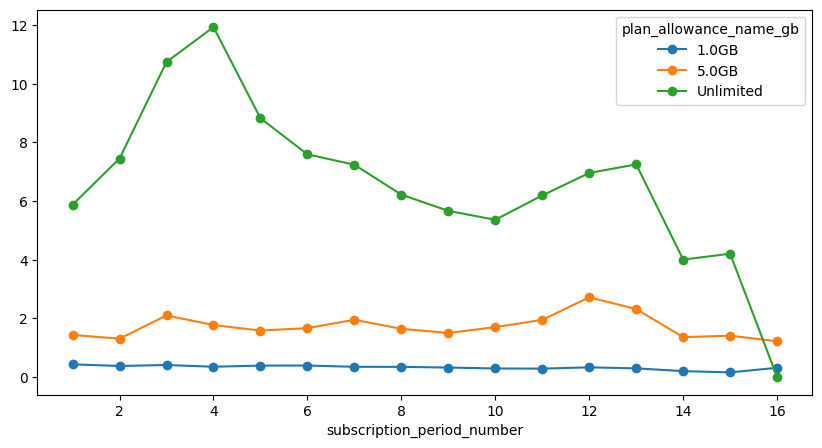

In [57]:
df_agg = (df.groupby(['subscription_period_number','plan_allowance_name_gb'], observed=True)['avg_usage_gb'].mean().unstack('plan_allowance_name_gb').sort_index())

df_agg.plot(kind='line', marker='o', figsize=(10,5))

### Quick Findings
- Usage looks stable for 1GB and 5GB and decreasing for Unlimited plans
- However, the y-axis scale distorts the much lower values for 1GB and 5GB
- We'll therefore plot each value on it's own y-axis

### Visualisation

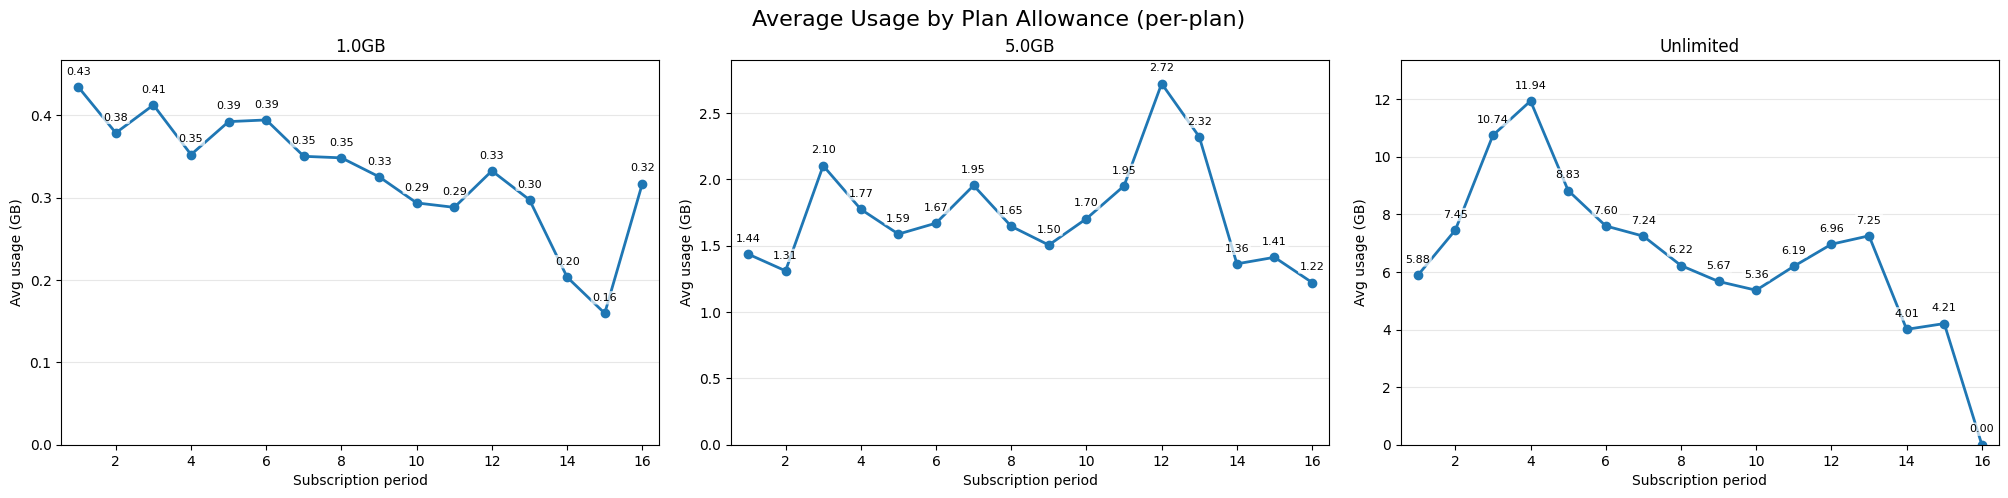

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharex=True, sharey=False, constrained_layout=False)
axes = axes.ravel()

for ax, col in zip(axes, df_agg.columns):
    y = df_agg[col]
    x = y.index.to_numpy()
    vals = y.to_numpy()

    ax.plot(x, vals, linewidth=2, marker='o', markevery=1)
    ax.set_title(col)
    ax.set_xlabel("Subscription period")
    ax.set_ylabel("Avg usage (GB)")
    ax.grid(axis='y', alpha=0.3)
    
  # --- give vertical breathing room ---
    if np.isfinite(vals).any():
        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)
        pad = 0.12 * (vmax - vmin if vmax > vmin else 1.0)   # 12% headroom/footroom
        ax.set_ylim(vmin - pad, vmax + pad)
    ax.margins(x=0.03, y=0.15)  # extra margins around data

    # --- annotate ALL points with a small offset and a white bbox ---
    for xi, yi in zip(x, vals):
        if np.isfinite(yi):
            ax.annotate(f"{yi:,.2f}", (xi, yi), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8, bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, lw=0))

for ax in axes:
    ax.set_ylim(bottom=0)

# add a bit more space between subplots
fig.subplots_adjust(hspace=0.25, wspace=0.12)   # ↑ tweak as needed
fig.suptitle("Average Usage by Plan Allowance (per-plan)", y=0.98, fontsize=16)
plt.show()

### Quick Findings

- Generally it looks like usage is only stable over time for the 5GB plan
- The unlimited plan data is somewhat misleading. It looks decreasing since we're drawn to the 4-month peak of 11.94 after which the data decreases
- However, if we didn't have these peaks, month 1 to month 12 would actually look pretty stable
- Further analysis required to identify this initial spike as a possible outlier with extremely high usage

# 4. Compare the retention pattern for the most recently launched project versus the two older ones.

### Query

In [66]:
## projects

query = """
with subscriptions_enriched as (
    select
          subscription_id
        , project_type
        , device_type
        , subscription_period_number
        , reporting_date
        , subscription_period_start
        , first_value(subscription_period_start) over (partition by subscription_id order by subscription_period_start asc) as subscription_start_date
    from usage_data ud
    left join projects p
        on ud.project_id__hashed = p.project_id__hashed
    --where device_type = 'Phones'
),

subscriptions_enriched_agg as (
    select
          date_trunc('month', subscription_start_date) as start_cohort
        , project_type
        , device_type
        , project_type || ': ' || device_type || ' (' || start_cohort || ')' as segment
        , count(distinct case when subscription_period_number = 1 then subscription_id end) as new_subscriptions
        , count(distinct case when subscription_period_number = 2 then subscription_id end) as subscriptions_retained_m1
        , round(count(distinct case when subscription_period_number = 2 then subscription_id end) / count(distinct case when subscription_period_number = 1 then subscription_id end) , 4) as retained_m1_pct
    from subscriptions_enriched
    where subscription_start_date >= '2025-04-01' and subscription_start_date < '2025-05-01'
    group by all
),

historical_connect_subscription_retention as (
    select
         '2024-03-01 to 2025-04-01' as start_cohort
        , project_type
        , device_type
        , project_type || ': ' || device_type || ' (' || start_cohort || ')' as segment
        , count(distinct case when subscription_period_number = 1 then subscription_id end) as new_subscriptions
        , count(distinct case when subscription_period_number = 2 then subscription_id end) as subscriptions_retained_m1
        , round(count(distinct case when subscription_period_number = 2 then subscription_id end) / count(distinct case when subscription_period_number = 1 then subscription_id end) , 4) as retained_m1_pct
    from subscriptions_enriched
    where subscription_start_date < '2025-05-01'
        and project_type = 'Connect'
    group by all
),

all_data as (
    select * from subscriptions_enriched_agg
        union all 
    select * from historical_connect_subscription_retention
)

select * from all_data order by 1,2

"""

df = sql_to_df(query)
df

,start_cohort,project_type,device_type,segment,new_subscriptions,subscriptions_retained_m1,retained_m1_pct
0,2024-03-01 to 2025-04-01,Connect,Wearables,Connect: Wearables (2024-03-01 to 2025-04-01),589,357,0.61
1,2024-03-01 to 2025-04-01,Connect,Phones,Connect: Phones (2024-03-01 to 2025-04-01),6588,5959,0.90
2,2025-04-01,API,Phones,API: Phones (2025-04-01),440,72,0.16
3,2025-04-01,Connect,Wearables,Connect: Wearables (2025-04-01),231,80,0.35
4,2025-04-01,Connect,Phones,Connect: Phones (2025-04-01),87,47,0.54


### Visualisation

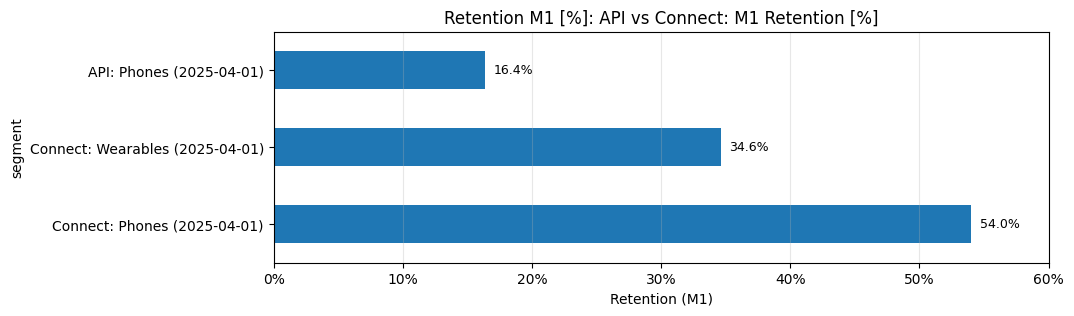

In [93]:
relevant_segments = ['API: Phones (2025-04-01)','Connect: Wearables (2025-04-01)', 'Connect: Phones (2025-04-01)']

plotdf = df[df['segment'].isin(relevant_segments)][['segment','retained_m1_pct']]


# enforce order
plotdf['segment'] = pd.Categorical(plotdf['segment'], categories=relevant_segments, ordered=True)
plotdf = plotdf.sort_values('segment')


# horizontal bar chart (values are 0–1 fractions)
ax = plotdf.set_index('segment')['retained_m1_pct'].plot(kind='barh', figsize=(10,3), legend=False)


ax.set_title('Retention M1 [%]: API vs Connect: M1 Retention [%]')
ax.set_xlabel('Retention (M1)')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0%}'))  # show as percentages
ax.set_xlim(0, 0.6)


# value labels on bars
for p in ax.patches:
    w = p.get_width()
    ax.annotate(f'{w:.1%}', (w, p.get_y() + p.get_height()/2),
                xytext=(6, 0), textcoords='offset points',
                va='center', ha='left', fontsize=9)


ax.invert_yaxis()  # show first item at the top
ax.grid(axis='x', alpha=0.3)
plt.show()

### Quick Findings
- Older cohorts have significantly higher retention rates than more recent ones. Would make sense to dive into this.
- Retention Rate is significantly lower for the API product, compared with other products.
- Are these products comparable? Are prior retention rates the best point of comparison to evalute initial success of API

# What I would do differently if this was an analysis I conducted within the company?


### 1. Use HEX 
- This is the perfect analysis for a tool like HEX, which I undersand is part if Gig's Data Stack
- Jupter Notebooks are great, the visualisation less so. Quick plots are fine, any enriched visualisation is way more time consuming than a dedicated BI Tool or Hex


### 2. Dive deeper into Subscription vs Project ID
- I made the quick assumption that "Subscription" is the "primary entity" to consider, the way we might for a Spotify or Netflix Subscription/
- However, Subscriptions are probably tied to "Organizations" (Project IDs?)". If that's the case, I would possibly approach the analysis differently and have very different findings. (🤞 I hope that's not the case and the findings above are therefore still sound)



# Additional Analyses based on findings above

### 1. Incporote Revenue as KPI
- We haven't considered Revenue at all, which is critical for any Subscription based company. How does Avg. Revenue per Subscription develop over time? What's Avg. Revenue by Plan?


### 2. Analyse Minutes usage in addition to Data Usage
- I've only analysed "Data" usage. I'd assume that's the primary usage, but for companies using Gigs to offer phone plans, minutes might actually be relevant/


### 3. Analyse the decrease in Retention Rate over time
- Recent cohorts are retaining at a far lower rate. Why? Are older cohorts simply comprised of those early dedicated users which often retain better? What about other segments such as Country, Telecom Networks etc.


### 4. Conduct statistical analyses on our API Product Retention Rate
- Even without a stat test, the decrease in retention here is certainly significant. However, it always makes sense to have statistical significant tests, especially if retention rates are more aligned across products


### 5. Avg. Data Use over time of the Unlimited Plan
- I'd like to investigate the spike in Months 0 - 4. Is this driven by an outlier? Is data usage of the unlimited plan actually stable over time?


### 6. Percentiles instead of Averages
- The segmentation of users by plan already gives us much more insights than the overall average would. This segmentation already helps with what would otherwise be outliers if analysing the entire data set.
- However, further segmentation would make sense. Generating usage percentiles within those segments would be critical for making concrete product recommendations. E.g. Which users are true power users? Which users should be try to upsell etc.